## Grao en Intelixencia Artificial. USC. Curso 2025/2026
## VISION POR COMPUTADOR 

### TEMA 5: Segmentación de imaxe   

#### Contornos (active contours models)

Na propia documentación da librería scikit-image atopamos un exemplo de *Active contour model*: https://scikit-image.org/docs/0.25.x/auto_examples/edges/plot_active_contours.html

Neste exemplo o modelo de contornos activos é utilizado para segmentar a cara da astronauta mediante o axuste dunha curva cerrada aos eixes da cara.
Primeiro hai que inicializar a curva de xeito que sexa posible facer este axuste automático. Neste caso debe rodear a cara.

Podedes probar a segmentar outros obxectos da imaxe. Que parámetros habería que modificar?

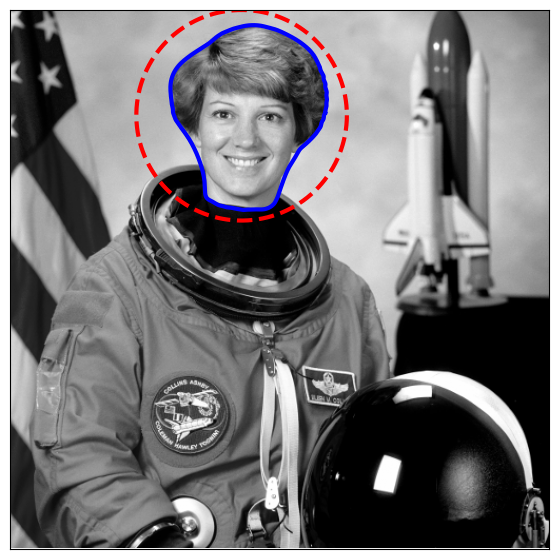

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import data
from skimage.filters import gaussian
from skimage.segmentation import active_contour

img = data.astronaut()
img = rgb2gray(img)

s = np.linspace(0, 2 * np.pi, 400)

r = 100 + 100 * np.sin(s)
c = 220 + 100 * np.cos(s)
init = np.array([r, c]).T

snake = active_contour(
    gaussian(img, sigma=3, preserve_range=False),
    init,
    alpha=0.015,
    beta=10,
    gamma=0.001,
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap=plt.cm.gray)
ax.plot(init[:, 1], init[:, 0], '--r', lw=3)
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=3)
ax.set_xticks([]), ax.set_yticks([])
ax.axis([0, img.shape[1], img.shape[0], 0])

plt.show()

#### Operacións morfolóxicas

Estas operacións pódense utilizar para eliminar ruido e mellorar a calidade das segmentacións.
En primeiro lugar imos ver cun exemplo sinxelo (imaxe de fondo negro e letras blancas) como se comportan estas operacións.

In [2]:
import cv2
from skimage.morphology import (erosion, dilation, closing, opening, area_closing, area_opening)

In [3]:
images_path = './images/'

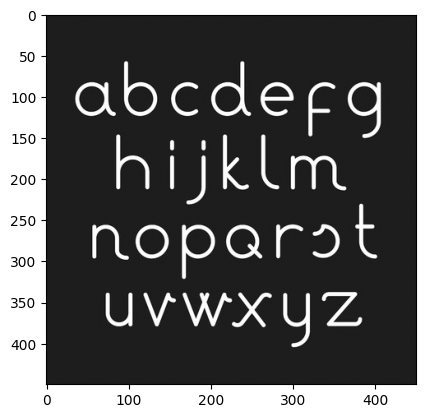

In [5]:
im_letras = cv2.imread(images_path + 'letras2_bn.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(im_letras, cmap='gray');

Agora definimos varios elementos estructurais (kernels), pódense definir moitos mais.

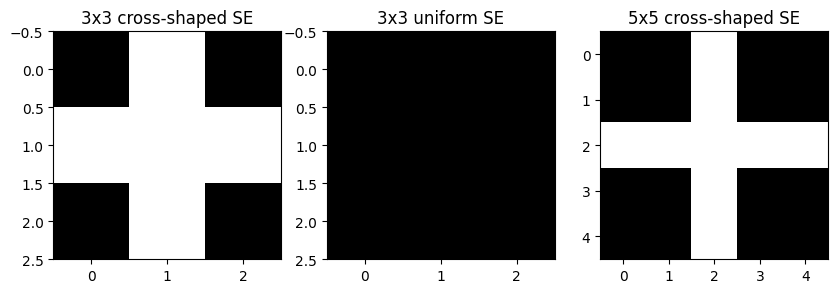

In [6]:
se3_cross = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]])

se3_unif = np.array([[1,1,1],
                     [1,1,1],
                     [1,1,1]])

se5_cross = np.array([[0,0,1,0,0],
                      [0,0,1,0,0],
                      [1,1,1,1,1],
                      [0,0,1,0,0],
                      [0,0,1,0,0]])


# Feel free to define and try more kernels

fig, ax = plt.subplots(1, 3, figsize=(10, 10))
ax[0].imshow(se3_cross, cmap='gray')
ax[0].set_title('3x3 cross-shaped SE')
ax[1].imshow(se3_unif, cmap='gray')
ax[1].set_title('3x3 uniform SE')
ax[2].imshow(se5_cross, cmap='gray')
ax[2].set_title('5x5 cross-shaped SE');

E vemos o efecto das distintas operacións cos distintos kernels (hai que cambialo)

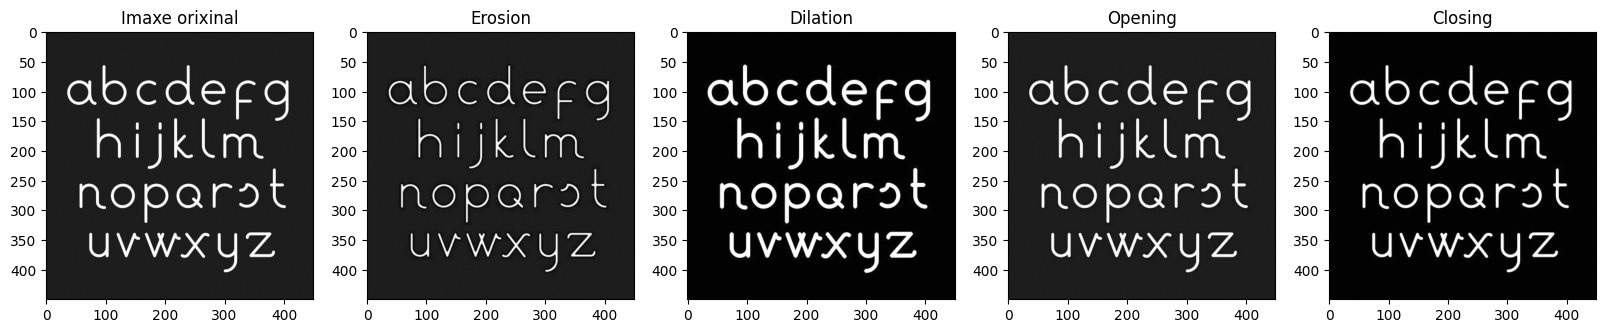

In [7]:
# erosion, dilation, closing, opening
eroded_cross33 = erosion(im_letras, se3_cross)
dilated_cross33 = dilation(im_letras, se3_cross)
opened_cross33 = opening(im_letras, se3_cross)
closed_cross33 = closing(im_letras, se3_cross)

plt.figure(figsize=(20, 10))
plt.subplot(1, 5, 1)
plt.imshow(im_letras, cmap='gray'), plt.title('Imaxe orixinal')
plt.subplot(1, 5, 2)
plt.imshow(eroded_cross33, cmap='gray'), plt.title('Erosion')
plt.subplot(1, 5, 3)
plt.imshow(dilated_cross33, cmap='gray'), plt.title('Dilation')
plt.subplot(1, 5, 4)
plt.imshow(opened_cross33, cmap='gray'), plt.title('Opening')
plt.subplot(1, 5, 5)
plt.imshow(closed_cross33, cmap='gray'), plt.title('Closing');

Tamén podemos visualizar as diferenzas (a resta por exemplo) con respecto á segmentación inicial, para ver mellor o **efecto da operación**:

(<matplotlib.image.AxesImage at 0x7f12e7259f90>, Text(0.5, 1.0, 'Closing'))

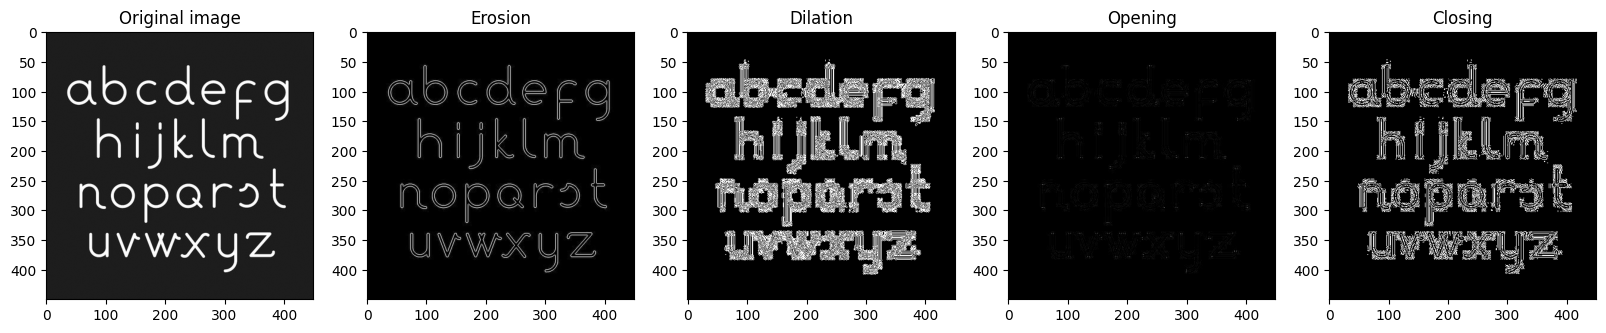

In [8]:
plt.figure(figsize=(20, 10))
plt.subplot(1, 5, 1)
plt.imshow(im_letras, cmap='gray'), plt.title('Original image')
plt.subplot(1, 5, 2)
plt.imshow(im_letras - eroded_cross33, cmap='gray'), plt.title('Erosion')
plt.subplot(1, 5, 3)
plt.imshow(im_letras - dilated_cross33, cmap='gray'), plt.title('Dilation')
plt.subplot(1, 5, 4)
plt.imshow(im_letras - opened_cross33, cmap='gray'), plt.title('Opening')
plt.subplot(1, 5, 5)
plt.imshow(im_letras - closed_cross33, cmap='gray'), plt.title('Closing')

Agora, nun caso mais "real", cargamos e visualizamos unha imaxe e a súa segmentación binaria. Trátase do TAC da semana pasada, pero con algo de **ruido** extra que trataremos de eliminar.

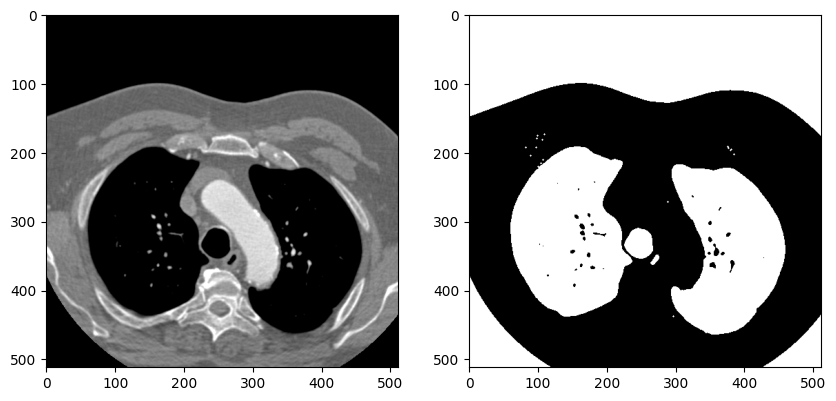

In [12]:
filename1 = images_path + 'CT.png'
filename2 = images_path + 'CT_lungs_noisy.png'
im_ct = cv2.imread(filename1, cv2.IMREAD_GRAYSCALE)
im_ct_lungs = cv2.imread(filename2, cv2.IMREAD_GRAYSCALE)
im_ct_lungs[np.where(im_ct_lungs==255)] = 1     # change from labels [0, 255] to [0, 1] to ease result's interpretation

fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[0].imshow(im_ct, cmap='gray')
ax[1].imshow(im_ct_lungs, cmap='gray');

#
area_opened_50 = area_opening(im_ct_lungs, area_threshold=50)
area_closed_10 = area_closing(im_ct_lungs, area_threshold=10)   

Utiliza o código anterior e modifica os parámetros necesarios para obter unha segmentación limpa dos pulmóns (excluíndo bronquios e bronquiolos)


**Area Opening** e **Area Closing** son operacions similares ás morfolóxicas pero con un elemento estructural **deformable** (sen forma fixa). Só ten un parámetro: area_threshold, que representa o tamaño total.


*   Con Area Opening o que se fai é, a groso modo, elimar elementos espurios que sexan mais pequenos que o valor de "area_threshold".
*   Con Area Closing o que se fai é, a groso modo, encher ocos que sexan mais pequenos que o valor de "area_threshold".

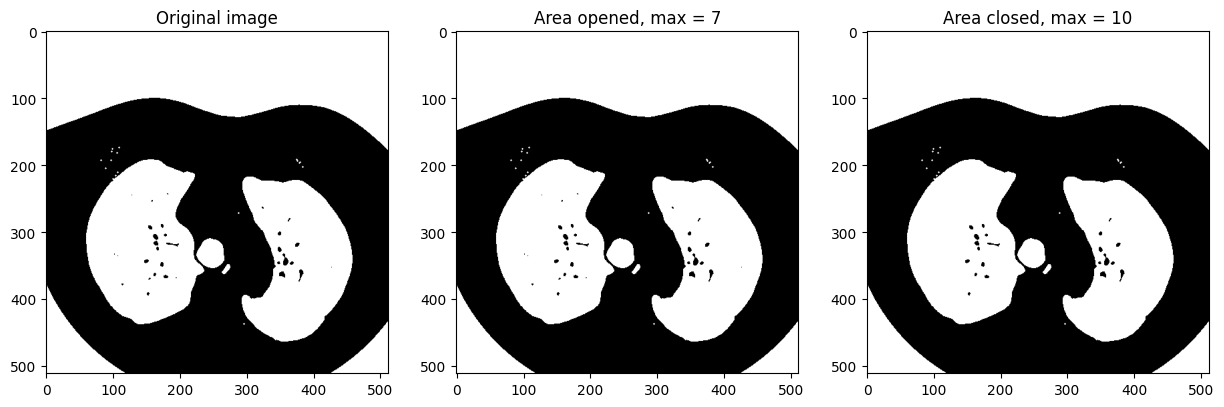

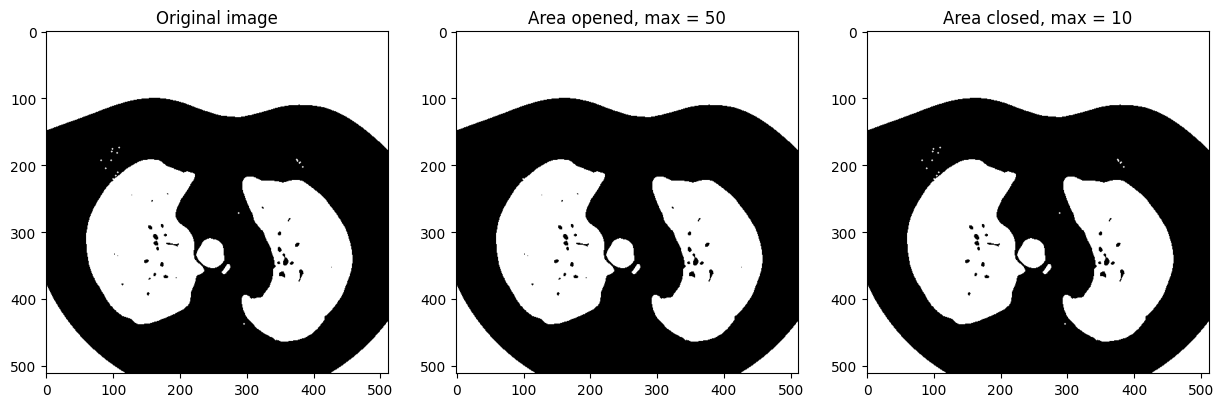

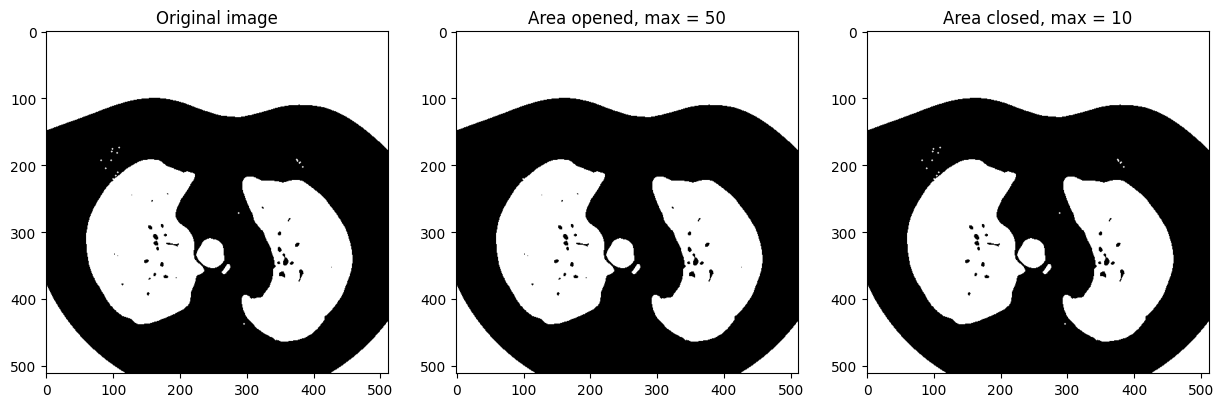

In [13]:
area_opened_7 = area_opening(im_ct_lungs, area_threshold=3)
area_closed_10 = area_closing(im_ct_lungs, area_threshold=10)

plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(im_ct_lungs, cmap='gray'), plt.title('Original image')

plt.subplot(1, 3, 2)
plt.imshow(area_opened_7, cmap='gray'), plt.title('Area opened, max = 7')

plt.subplot(1, 3, 3)
plt.imshow(area_closed_10, cmap='gray'), plt.title('Area closed, max = 10');

# You can try different area thresholds to see their effect on the result
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(im_ct_lungs, cmap='gray'), plt.title('Original image')   

plt.subplot(1, 3, 2)
plt.imshow(area_opened_50, cmap='gray'), plt.title('Area opened, max = 50')     

plt.subplot(1, 3, 3)
plt.imshow(area_closed_10, cmap='gray'), plt.title('Area closed, max = 10');

# You can try different area thresholds to see their effect on the result
plt.figure(figsize=(15, 10))
plt.subplot(1, 3, 1)
plt.imshow(im_ct_lungs, cmap='gray'), plt.title('Original image')
plt.subplot(1, 3, 2)
plt.imshow(area_opened_50, cmap='gray'), plt.title('Area opened, max = 50')
plt.subplot(1, 3, 3)
plt.imshow(area_closed_10, cmap='gray'), plt.title('Area closed, max = 10');